# Lab 09：推論——KV cache、批次、speculative decoding、量化

對應講義：[第 09 課](../lessons/09_inference.md)

需要 Lab 06 存下的 `checkpoints/base_model.pt`。

1. KV cache：結果不變、時間從平方變線性（§2.1），以及 cache 的大小（式 9.1）
2. decode 是記憶體受限的：批次越大，每個 token 越便宜（§2.2）
3. speculative decoding：訓練一個小草稿模型，量接受率、驗證分布不變（式 9.3、9.4）
4. 量化：8／4／3 位元，每列一個係數 vs 整個矩陣一個係數（式 9.5）

CPU 約 4 分鐘。

In [1]:
import math
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)

In [2]:
from lm_course.artifacts import course_tokenizer, course_tokens, load_base_model

tok = course_tokenizer()
model = load_base_model()
train_tokens, val_tokens = course_tokens(tok)
bos = tok.special_id("<|bos|>")
print(f"base model: {model.num_parameters():,} parameters, context {model.config.context_length}")

base model: 5,242,880 parameters, context 256


## 1. KV cache

In [3]:
from lm_course.sampling import generate

prompt = [bos] + tok.encode("Once upon a time, there was a little bird")
with_cache = generate(model, prompt, 100, temperature=1.0, generator=torch.Generator().manual_seed(3))
without = generate(model, prompt, 100, temperature=1.0, use_cache=False, generator=torch.Generator().manual_seed(3))
print("identical outputs:", with_cache == without)
print(tok.decode(prompt[1:] + with_cache[0]))

identical outputs: True
Once upon a time, there was a little bird named Blue. Blue was rabbit very independent. He loved to fly around all day long. One day, while flying, the clouds began to change. 
One day, Blue could not see and cough she was a problem for it. She heard the noise and tried to get out. But she could not find him. She was scared.
Then, a small bird saw Blue coming. The bird was sad and needed help. Will bravely flew up to The bird and said, "Don't


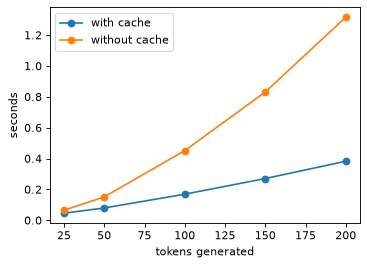

  25 tokens: 0.05s with cache, 0.07s without (1.4x)
  50 tokens: 0.08s with cache, 0.15s without (1.9x)
 100 tokens: 0.17s with cache, 0.45s without (2.7x)
 150 tokens: 0.27s with cache, 0.83s without (3.1x)
 200 tokens: 0.38s with cache, 1.32s without (3.4x)


In [4]:
lengths = [25, 50, 100, 150, 200]
times = {"with cache": [], "without cache": []}
for n in lengths:
    for name, use_cache in [("with cache", True), ("without cache", False)]:
        start = time.perf_counter()
        generate(model, [bos], n, temperature=1.0, use_cache=use_cache, generator=torch.Generator().manual_seed(0))
        times[name].append(time.perf_counter() - start)
plt.figure(figsize=(5, 3.5))
for name, ts in times.items():
    plt.plot(lengths, ts, "o-", label=name)
plt.xlabel("tokens generated")
plt.ylabel("seconds")
plt.legend()
plt.show()
for n, a, b in zip(lengths, times["with cache"], times["without cache"]):
    print(f"{n:4d} tokens: {a:.2f}s with cache, {b:.2f}s without ({b / a:.1f}x)")

用 cache 的時間大約隨長度線性成長；不用 cache 的時間長得比線性快（每一步都重算整段前文：長度加倍，時間約 2.5–3 倍；若沒有固定開銷，會趨近平方的 4 倍）。很短的生成（25 個 token）差距很小：這時固定開銷比重算還貴。

**cache 有多大**（式 9.1，bf16）：

In [5]:
from lm_course.model import GPTConfig, gpt2_config, llama_style_config
from lm_course.scaling import kv_cache_bytes

configs = {
    "this course's model (fp32)": (model.config, 256, 4),
    "GPT-2 small, 1024 tokens": (gpt2_config("gpt2"), 1024, 2),
    "7B-class MHA (L=32, d=4096), 4096 tokens": (llama_style_config(n_layer=32, d_model=4096, n_head=32), 4096, 2),
    "same with GQA, 8 KV heads": (llama_style_config(n_layer=32, d_model=4096, n_head=32, n_kv_head=8), 4096, 2),
}
for name, (cfg, T, nbytes) in configs.items():
    per_token = kv_cache_bytes(cfg, 1, 1, nbytes)
    print(f"{name:<42} {per_token / 1024:8.1f} KB/token   {kv_cache_bytes(cfg, 1, T, nbytes) / 1e6:9.1f} MB per sequence")

this course's model (fp32)                      8.0 KB/token         2.1 MB per sequence
GPT-2 small, 1024 tokens                       36.0 KB/token        37.7 MB per sequence
7B-class MHA (L=32, d=4096), 4096 tokens      512.0 KB/token      2147.5 MB per sequence
same with GQA, 8 KV heads                     128.0 KB/token       536.9 MB per sequence


## 2. decode 是記憶體受限的

同一個 prompt 批次生成 $B$ 個樣本（`num_samples=B`），量每產生一個 token 的平均時間。

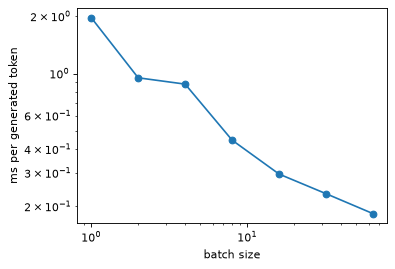

batch   1:   1.97 ms/token  (    508 tokens/s)
batch   2:   0.95 ms/token  (   1053 tokens/s)
batch   4:   0.88 ms/token  (   1137 tokens/s)
batch   8:   0.45 ms/token  (   2241 tokens/s)
batch  16:   0.30 ms/token  (   3379 tokens/s)
batch  32:   0.23 ms/token  (   4286 tokens/s)
batch  64:   0.18 ms/token  (   5455 tokens/s)


In [6]:
batch_sizes = [1, 2, 4, 8, 16, 32, 64]
per_token = []
for B in batch_sizes:
    start = time.perf_counter()
    generate(model, prompt, 50, temperature=1.0, num_samples=B, generator=torch.Generator().manual_seed(0))
    per_token.append((time.perf_counter() - start) / (50 * B))
plt.figure(figsize=(5, 3.5))
plt.loglog(batch_sizes, [t * 1e3 for t in per_token], "o-")
plt.xlabel("batch size")
plt.ylabel("ms per generated token")
plt.show()
for B, t in zip(batch_sizes, per_token):
    print(f"batch {B:3d}: {t * 1e3:6.2f} ms/token  ({1 / t:7.0f} tokens/s)")

batch 從 1 變大時，每個 token 的成本大幅下降：讀一次權重，服務更多序列（講義式 9.2）。這個小模型在 CPU 上還有很多 Python 開銷，但趨勢和 GPU 上一樣。

## 3. Speculative decoding

草稿模型：和 base model 共用 tokenizer、只有 1 層、寬 128，在 TinyStories 上訓練 400 步（約 2.5 分鐘）。

In [7]:
from lm_course.artifacts import base_model_config
from lm_course.model import GPT
from lm_course.optim import build_optimizer, wsd_schedule
from lm_course.training import evaluate, train

set_seed(0)
draft = GPT(base_model_config(n_layer=1, d_model=128, n_head=2))
result = train(draft, train_tokens, val_tokens, num_steps=400, batch_size=32,
               optimizer=build_optimizer(draft, "muon", lr=3e-3, muon_lr=0.02),
               schedule=wsd_schedule, warmup=20, eval_every=400, log_every=0)
target_loss = evaluate(model, val_tokens, 256, max_batches=10).loss
print(f"draft: {draft.num_parameters():,} params, val loss {result.final_eval_loss:.3f} ({result.seconds:.0f}s); target val loss {target_loss:.3f}")

draft: 1,245,184 params, val loss 2.813 (154s); target val loss 1.986


In [8]:
from lm_course.sampling import speculative_generate

prompt = [bos] + tok.encode("Lily and Ben went to the park")
rows = []
for k in (1, 2, 4, 6):
    out, stats = speculative_generate(model, draft, prompt, 120, num_draft=k, generator=torch.Generator().manual_seed(0))
    alpha = stats.acceptance_rate
    rows.append((k, alpha, 120 / stats.target_calls, (1 - alpha ** (k + 1)) / (1 - alpha)))
    print(f"k={k}: acceptance {alpha:.2f}, tokens per target call {120 / stats.target_calls:.2f} (formula 9.4: {rows[-1][3]:.2f})")
print()
print(tok.decode(prompt[1:] + out))

k=1: acceptance 0.64, tokens per target call 1.64 (formula 9.4: 1.64)


k=2: acceptance 0.51, tokens per target call 1.76 (formula 9.4: 1.78)


k=4: acceptance 0.56, tokens per target call 2.11 (formula 9.4: 2.14)


k=6: acceptance 0.54, tokens per target call 2.14 (formula 9.4: 2.15)

Lily and Ben went to the park with Mom and Dad. They saw birds, birds, and a long see began to dance. Mom walked into the park and saw a big buckle on the ground.
"What are you doing, children?" Mom asked. "Why are you being so fearful?" Lily asked.
Mom and Dad were surprised. They laughed and thought Lily had lost her toy. It had made a big mess on it. Mom said they were sad and angry, but then she pulled it out of the park.
"Ben, where isn't?" Mom asked.
"I dropped this bone at the ground," Lily said. "That


每次呼叫目標模型能產生超過一個 token；實測值和式 (9.4) 的預測相近（公式假設每個位置的接受機率相同，實際上會隨位置而變）。

**分布真的沒變嗎？** 對同一個前文，比較「直接從目標模型抽第一個 token」與「speculative decoding 的第一個 token」各 3,000 次的分布。

In [9]:
from lm_course.sampling import next_token_probs, sample_from, speculative_step

context = [bos] + tok.encode("The cat sat on the")
with torch.no_grad():
    p_target = next_token_probs(model(torch.tensor([context]))[0, -1:])[0]


def target_probs(seq: list[int]) -> torch.Tensor:
    with torch.no_grad():
        return next_token_probs(model(torch.tensor([seq]))[0, -3:])


def draft_probs(seq: list[int]) -> torch.Tensor:
    with torch.no_grad():
        return next_token_probs(draft(torch.tensor([seq]))[0, -1:])[0]


g = torch.Generator().manual_seed(0)
trials = 3000
counts = torch.zeros(tok.vocab_size)
for _ in range(trials):
    counts[speculative_step(target_probs, draft_probs, context, 2, g)[0]] += 1
top = torch.topk(p_target, 6).indices
print(f"{'token':>10} {'target p':>9} {'speculative':>12}")
for i in top:
    print(f"{tok.decode([int(i)])!r:>10} {p_target[i]:9.3f} {counts[i] / trials:12.3f}")
direct = torch.bincount(torch.multinomial(p_target, trials, replacement=True, generator=g), minlength=tok.vocab_size)
tv = 0.5 * (counts / trials - p_target).abs().sum().item()
tv_noise = 0.5 * (direct / trials - p_target).abs().sum().item()
print(f"total variation distance to the target: speculative {tv:.3f}; "
      f"{trials} draws straight from the target {tv_noise:.3f} (pure sampling noise)")

     token  target p  speculative
  ' floor'     0.340        0.334
  ' grass'     0.183        0.190
  ' porch'     0.077        0.081
  ' couch'     0.060        0.064
  ' table'     0.036        0.035
 ' ground'     0.032        0.028
total variation distance to the target: speculative 0.081; 3000 draws straight from the target 0.079 (pure sampling noise)


兩個距離一樣大：speculative decoding 和「直接從目標模型抽」的差別，完全在抽樣雜訊之內（`tests/test_sampling.py` 用 2 萬次抽樣做了更嚴格的檢查）。

## 4. 量化

把每個 `Linear` 的權重做 absmax 量化再還原（式 9.5），看驗證 loss 與權重大小。再比較「每列一個係數」與「整個矩陣一個係數」。

In [10]:
from lm_course.quantization import fake_quantize, quantize_model, weight_bytes

base = evaluate(model, val_tokens, 256, max_batches=20)
print(f"{'fp32':>6}: val loss {base.loss:.4f}   weights {weight_bytes(model, 32) / 1e6:.1f} MB")
for bits in (8, 4, 3):
    q = quantize_model(model, bits)
    r = evaluate(q, val_tokens, 256, max_batches=20)
    print(f"{bits:>4}-bit: val loss {r.loss:.4f} (+{r.loss - base.loss:.4f})   weights {weight_bytes(model, bits) / 1e6:.1f} MB")

  fp32: val loss 1.9746   weights 21.0 MB


   8-bit: val loss 1.9747 (+0.0001)   weights 8.4 MB


   4-bit: val loss 2.0294 (+0.0549)   weights 6.3 MB


   3-bit: val loss 2.4055 (+0.4309)   weights 5.8 MB


In [11]:
import copy

def quantize_per_tensor(m: torch.nn.Module, bits: int) -> torch.nn.Module:
    out = copy.deepcopy(m)
    with torch.no_grad():
        for module in out.modules():
            if isinstance(module, torch.nn.Linear):
                w = module.weight
                module.weight.copy_(fake_quantize(w.reshape(1, -1), bits).reshape(w.shape))
    return out

for bits in (8, 4):
    per_row = evaluate(quantize_model(model, bits), val_tokens, 256, max_batches=20).loss
    per_tensor = evaluate(quantize_per_tensor(model, bits), val_tokens, 256, max_batches=20).loss
    print(f"{bits}-bit: per-row scales {per_row - base.loss:+.4f}, one scale per matrix {per_tensor - base.loss:+.4f}")

w = model.lm_head.weight.detach()
row_max = w.abs().amax(dim=1)
print(f"\nLM head: largest |w| per row ranges from {row_max.min():.3f} to {row_max.max():.3f}; "
      f"with one scale per matrix, the rows with small weights only use about {int(7 * row_max.median() / row_max.max())} of the 7 positive 4-bit levels")

8-bit: per-row scales +0.0001, one scale per matrix +0.0009


4-bit: per-row scales +0.0549, one scale per matrix +0.2591

LM head: largest |w| per row ranges from 0.186 to 1.262; with one scale per matrix, the rows with small weights only use about 1 of the 7 positive 4-bit levels


In [12]:
q4 = quantize_model(model, 4)
g = torch.Generator().manual_seed(5)
prompt = [bos] + tok.encode("One day, a little dog")
for name, m in [("fp32", model), ("4-bit", q4)]:
    out = generate(m, prompt, 80, temperature=0.8, top_k=50, stop_tokens={bos}, generator=torch.Generator().manual_seed(5))[0]
    print(f"--- {name} ---")
    print(tok.decode(prompt[1:] + [t for t in out if t != bos]))

--- fp32 ---
One day, a little dog named Tim found a big piece of paper. He was very excited. He wanted to draw with the picture with his friends. Tim asked his friend, "Can I draw with the scissors?" His friend said, "Of course! Let's draw together."
Tim and his friend started to draw on the paper. They drew a big sun, a yellow bird, and a red ball. They had many


--- 4-bit ---
One day, a little dog named Tim found a ball. The ball was green and had a big smile. Tim wanted to play with the ball, but he did not know how.
Then, a big dog came by. The dog was kind and nice. Tim put the ball on the ground. The dog was sad because he could not play with the ball. The dog saw Tim's face and did not get the ball.



## 小結

- KV cache 讓生成從平方變線性，代價是和 context、batch、層數、KV head 數成正比的記憶體。
- decode 讀一次權重只產生一個 token，所以批次化是推論效率的關鍵。
- speculative decoding 在不改變分布的前提下，讓每次呼叫大模型產生多個 token。
- 每列一個係數的 absmax 量化：8 位元幾乎無損；位元越少，係數的粒度越重要。

下一步：[第 10 課](../lessons/10_data.md)——訓練資料從哪裡來、怎麼清理。